[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gamayos/finite-ring-space/blob/main/src/32-dark/32-dark-main.ipynb)

## The Dark Sector over Finite Relational Substrate (Akhtman, Geifman & Voether, 2026)

**Validation Package.** `finite-ring-space/src/32-dark` — the paper's twelve validation scripts and its figure script as written,
run through one registry: a family check is one script (`dark.<stem>`), its micro-checks the script's own verdict lines (four of the
thirteen print one) together with the registry's predicates, which decide the stated values explicitly where a script prints
without asserting — the exact Gauss law and the amplitude identity recomputed, the slopes 1.03/1.11 and the exact slope 1, the
0.051 discriminant and the two pinning checks of B8, the first-passage reduction, the SPARC scatter 0.038 dex and the bound
δα ≲ 3.5°, the prediction numerals; `rar_shape.py`, the named test of row B8 owed by the paper's Appendix A, is delivered here.
Each family names the row(s) of the paper's predicate ledger it witnesses (the paper's Appendix "Predicate ledger", rows cited as
`32:XN`; public copy at `docs/32-dark/32-dark-ledger.html`), and the ledger's source column cites the family ids in return.
Master-ledger rows of the corpus sourced from this paper: `00:L1`, `00:L7`, `00:Z7`, `00:D3`, `00:N1`, `00:N2`.

**Kinds** — three, recorded per family. `EXACT`: exact rationals, Z[i] or 60-digit identities, no tolerance in the verdict.
`SIM`: a seeded stochastic simulation (the noisy link, the killed walk), verdict by stated tolerance. `CHART`: a continuum reading
or a comparison with data (the interpolation, the RAR/BTFR, the SPARC scatter, the predictions, the cluster illustration), tagged
[approx] in the paper, verdict by stated tolerance.

**Run.** Cell by cell, or *Runtime → Run all*; ≈ 30 s on Colab (numpy, mpmath, matplotlib, scipy are present there). The scripts
write their figures and `deep.json` into `out/`, the paper's two figures into `figures/`; every figure a script saves gets a PNG
sibling, shown inline below its family's output. The last cell writes `results.json` and fails loudly if any family fails.

In [1]:
# --- environment: clone the package if this notebook is not already running inside it (Colab). numpy, mpmath, matplotlib and scipy are present on Colab.
import os
if not os.path.exists("darkcommon.py"):
    if not os.path.exists("finite-ring-space"):
        !git clone --filter=blob:none --sparse https://github.com/gamayos/finite-ring-space.git
        os.chdir("finite-ring-space")
        !git sparse-checkout set src/32-dark
        os.chdir("src/32-dark")
    else:
        os.chdir("finite-ring-space/src/32-dark")
print("working directory:", os.path.join(*os.getcwd().split(os.sep)[-3:]))

working directory: finite-ring-space/src/32-dark


In [2]:
import importlib, darkcommon as gc
importlib.reload(gc)         # a fresh registry if the notebook is re-run
print("families registered:", len(gc.LABELS))

families registered: 13


## The exact core: Gauss law, amplitude = √count, first passage
The discrete Gauss law of the synchronisation flux in exact rationals (Newton as the high-acceleration reading); the amplitude identity |Σ|² = n² coherent, ⟨|Σ|²⟩ = n incoherent, exact in Z[i] — the cross-term cancellation behind the deep-regime square root; the finite-cycle first-passage law at 60 digits (f(e^(−s)) = e^(−arccosh e^s), the √(2s) reduction with rel.err/s → 1/6, the wrap correction of the killed walk on Z_N); the seeded meridian walk collapsing onto e^(−a√(2s)) and the assembled resolved fraction 1 − e^(−√x).

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `dark.flux_exact` | `flux_exact.py` | EXACT | the discrete Gauss law of the synchronisation flux in exact rationals on the 5³ box: a unit point source gives unit flux through both enclosing surfaces, a source-free noise field gives zero, their superposition gives one — Newton's law as the high-acceleration reading | 32:C1, 32:X1 |
| `dark.born_exact` | `born_exact.py` | EXACT | amplitude = √count, exact in Z[i]: n aligned unit phasors have |Σ|² = n² (coherent, amplitude n) and the mean of |Σ|² over all sign patterns is n (incoherent, amplitude √n) for n up to 10 — the cross-term cancellation that forces the deep-regime square root | 32:C3, 32:C7 |
| `dark.firstpassage_finite` | `firstpassage_finite.py` | EXACT | the finite-cycle first-passage law at 60 digits: the single-step identity f(e^(−s)) = e^(−arccosh e^s); the reduction arccosh(e^s) = √(2s)(1 + s/6 + …) with rel.err/s → 1/6, carrier-exact to ~10⁻⁶¹ at s ~ Ω^(−1/2); the wrap correction of the killed walk on Z_N against the infinite line, O(e^(−(N−a) arccosh e^s)) | 32:B8, 32:C7 |
| `dark.meridian_walk` | `meridian_walk.py` | SIM | the meridian killed walk: the exact rational discriminant 1 − z² of the first-passage quadratic; the simulated escape probability against e^(−a√(2s)) (seeded); the assembled resolved fraction 1 − e^(−√x) with deep slope 1/2 (the RAR fit form); the mechanism figure | 32:B8, 32:C6, 32:C7 |

Ledger rows witnessed: 32:B8, 32:C1, 32:C3, 32:C6, 32:C7, 32:X1.


— flux_exact.py


EXACT discrete Gauss law (rational):
  unit point source: flux(R=0) = 1   (enclosed = 1)
  unit point source: flux(R=1) = 1   (enclosed = 1)
  source-free noise field: flux(R=1) = 0   (no enclosed source -> 0)
  source+noise: flux(R=1) = 1   == source-alone 1 ? True
PASS
PASS unit point source: flux = 1 exactly through the R = 0 and R = 1 surfaces
PASS source-free noise field: flux = 0 exactly
PASS source + noise: flux = 1 exactly (superposition)
  [PASS] dark.flux_exact        EXACT  [32:C1, 32:X1] the discrete Gauss law of the synchronisation flux in exact rationals on the 5³ box: a uni  --  4 checks, 0.1 s

— born_exact.py
coherent  |sum|^2 = n^2  exact for n=1,2,3,5,8  -> amplitude = n (Newtonian, 1st moment)
incoherent <|sum|^2> = n  exact (mean over all sign patterns) -> amplitude = sqrt(n) (2nd moment)
PASS: amplitude=sqrt(count) is the exact Born statement; the deep-regime square root is forced.
PASS coherent stack: |Σ|² = n² exactly for n = 1 … 10
PASS incoherent ensemble: ⟨|Σ

  N=  80 a=5 s=0.05:  cycle=0.203041002549  line=0.203041002509  |diff|=3.94e-11  (~e^-(N-a)arccosh(e^s)=4.1e-11)


  N= 200 a=8 s=0.02:  cycle=0.200821539493  line=0.200821539493  |diff|=1.78e-17  (~e^-(N-a)arccosh(e^s)=1.9e-17)
  -> wrap correction vanishes ~ e^{-(N-a)}; for a << sqrt(Omega) it is carrier-negligible.

VERDICT
  * the exact carrier transform is e^{-a arccosh(e^s)} (A), an identity;
  * its reduction to the Brownian e^{-a sqrt(2s)} = e^{-sqrt x} has relative
    error O(s) = O(Omega^{-1/2}) ~ 1e-61 at the substrate step (B);
  * on the finite cycle the wrap correction is O(e^{-(N-a) arccosh(e^s)}), negligible for a
    barrier below the coherence horizon sqrt(Omega) (C).
  => e^{-sqrt x} is the resolvable-window reading of an exact finite-cycle
     law, carrier-exact to O(Omega^{-1/2}); independently it is the amplitude
     identity of Proposition prop:born (exact in Z[i]).
PASS f(e^(−s)) = e^(−arccosh e^s) at s = 0.1 to 50 digits
PASS rel.err/s = 0.166667 → 1/6 at s = 10⁻⁴


PASS finite cycle N = 200, a = 8, s = 0.02: |cycle − line| = 1.78e-17 < 10⁻¹⁵ (the wrap correction)
  [PASS] dark.firstpassage_finite EXACT  [32:B8, 32:C7] the finite-cycle first-passage law at 60 digits: the single-step identity f(e^(−s)) = e^(−  --  3 checks, 12.3 s

— meridian_walk.py
  z=1/2: first-passage quadratic discriminant 1-z^2 = 3/4 (exact); sqrt is the meridian first-passage root
  z=1/3: first-passage quadratic discriminant 1-z^2 = 8/9 (exact); sqrt is the meridian first-passage root
  z=3/5: first-passage quadratic discriminant 1-z^2 = 16/25 (exact); sqrt is the meridian first-passage root
  => the per-step first-passage factor carries sqrt(1-z^2); a-level escape = f1(z)^a.

 collapse test: P_escape vs a*sqrt(2q) against e^{-a sqrt(2q)}
     a      q a*sqrt(2q)   P_sim   e^-()
     3  0.020      0.600   0.541   0.549


     5  0.020      1.000   0.364   0.368


     8  0.020      1.600   0.197   0.202


     5  0.010      0.707   0.492   0.493
     5  0.040      1.414   0.240   0.243


    10  0.010      1.414   0.237   0.243

 assembled resolution f(x) vs McGaugh 1-e^{-sqrt x}: True
 deep slope of g_obs 0.514 (->1/2); g_obs=g_bar/(1-e^-sqrt x) is the RAR fit.


figure saved


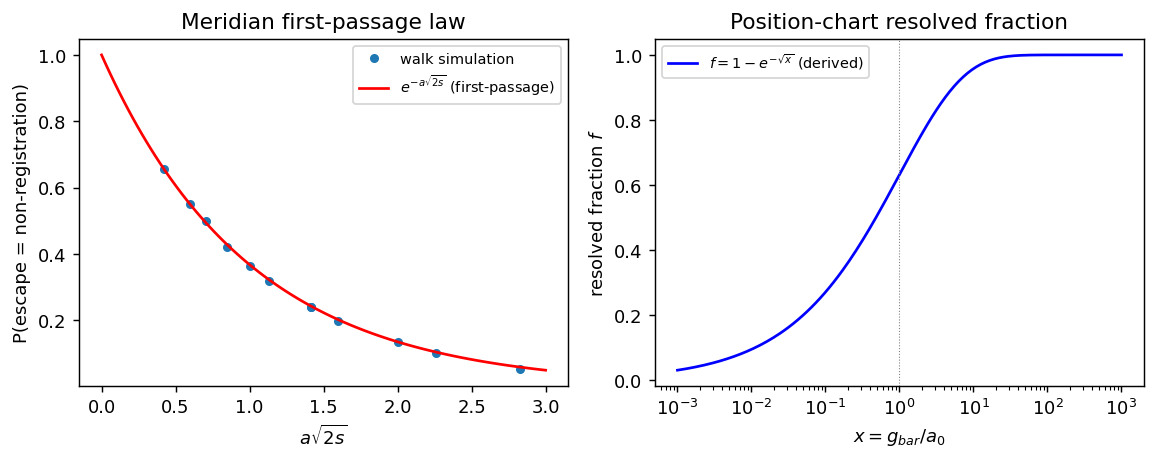

PASS the first-passage quadratic (z/2)f² − f + z/2 = 0 holds exactly at z = 3/5 with f = (1 − √(1 − z²))/z = 1/3


PASS seeded walk a = 5, q = 0.02: P_escape = 0.364 against e^(−a√(2q)) = 0.368 within 0.03
PASS deep slope of g_obs = g_b/(1 − e^(−√x)) below x = 10⁻² is 0.514 (→ 1/2)
PASS the figure written (cons3_firstpassage.pdf, .png)
  [PASS] dark.meridian_walk     SIM    [32:B8, 32:C6, 32:C7] the meridian killed walk: the exact rational discriminant 1 − z² of the first-passage quad  --  4 checks, 4.1 s


In [3]:
for fam in ["dark.flux_exact", "dark.born_exact", "dark.firstpassage_finite", "dark.meridian_walk"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)

## The noisy link: registration, not force modification
The noisy Kuramoto (Adler) link simulated and solved: the mean response is Newtonian at every noise level (deep slopes 1.03 and 1.11 by simulation, exactly 1 by the stationary Fokker–Planck solution), the boost constant to rising — the √ law is a property of registration, not of the mean force.

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `dark.deep_regime` | `deep_regime.py` | SIM | the noisy Kuramoto (Adler) link dφ = (T − sin φ)dt + √(2D) dW, seeded: the mean response is Newtonian at every noise level (deep slopes 1.03 at D = 0.3 and 1.11 at D = 0.6, the boost constant to rising) — the √ law is registration, not force modification; deep.json and the figure | 32:C4 |
| `dark.deep_regime_fp` | `deep_regime_fp.py` | CHART | the stationary Fokker–Planck solution of the same link: the small-tilt log-slope exactly 1 at D = 0.3 and 0.6 (within 2 × 10⁻³), the boost constant to rising; no √ regime in the mean force | 32:C4 |

Ledger rows witnessed: 32:C4.


— deep_regime.py


D=0.3: deep slope d ln g_eff/d ln g_N = 1.027  (Newtonian 1.0, MOND 0.5)
   boost g_eff/g_N = [0.971 1.002 1.008 1.019 1.028 1.069]  ~ constant => Newtonian-shaped


D=0.6: deep slope d ln g_eff/d ln g_N = 1.110  (Newtonian 1.0, MOND 0.5)
   boost g_eff/g_N = [1.211 1.352 1.392 1.408 1.443 1.552]  ~ constant => Newtonian-shaped


figure saved


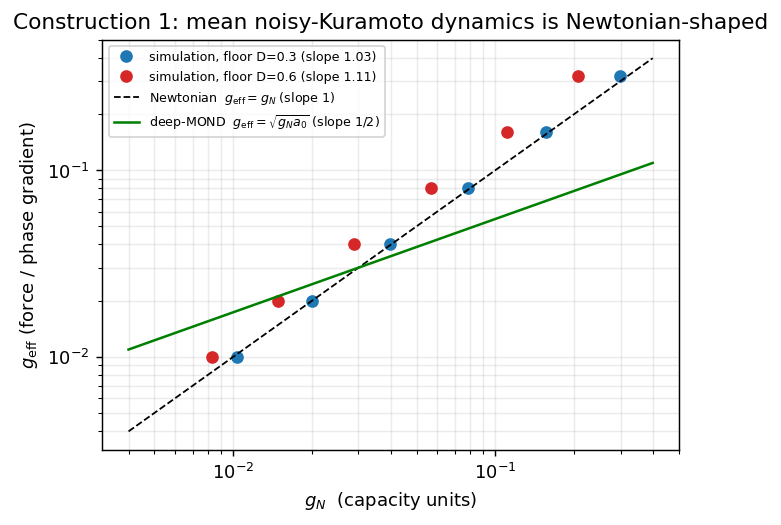

PASS D = 0.3: deep slope 1.027 (the paper's 1.03)
PASS D = 0.6: deep slope 1.110 (the paper's 1.11)
PASS the boost g_eff/g_N is constant to rising at both D (no √ regime)
PASS deep.json and the figure written (cons1_deepregime.pdf, .png)
  [PASS] dark.deep_regime       SIM    [32:C4] the noisy Kuramoto (Adler) link dφ = (T − sin φ)dt + √(2D) dW, seeded: the mean response i  --  4 checks, 3.4 s

— deep_regime_fp.py


D=0.3: small-tilt log-slope d ln g_eff/d ln g_N = 1.0004   boost g_eff/g_N = [1.025 1.025 1.025 1.027 1.035 1.072]


D=0.6: small-tilt log-slope d ln g_eff/d ln g_N = 1.0010   boost g_eff/g_N = [1.429 1.43  1.431 1.438 1.463 1.568]
PASS: mean response Newtonian (slope 1) at every D; boost constant to rising; no sqrt regime
PASS the script's verdict: mean response Newtonian (slope 1 within 2 × 10⁻³) at D = 0.3 and 0.6, boost constant to rising
PASS the two slopes ['1.0004', '1.0010'] within 2 × 10⁻³ of 1
  [PASS] dark.deep_regime_fp    CHART  [32:C4] the stationary Fokker–Planck solution of the same link: the small-tilt log-slope exactly 1  --  3 checks, 1.3 s


In [4]:
for fam in ["dark.deep_regime", "dark.deep_regime_fp"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)

## The interpolation against the radial acceleration relation
The interpolation g_obs = g_b/(1 − e^(−√x)) from the rotation angle: deep slope 1/2, Newtonian slope 1, the 0.051 discriminant against the simple rational form at x = 5.2, the two pinning checks of B8; the named test of B8 against the binned SPARC relation (data/RAR.mrt): the exponential form's free a₀ within 10 % of the RAR fit, the departures in the band 2 < x < 10 within the bin scatter; the two-chart Gauss law with a₀ = cH₀/2π, the RAR and BTFR slopes and the exponential-disk rotation curve.

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `dark.interpolation` | `interpolation.py` | CHART | the interpolation from the rotation angle: deep slope 1/2 and Newtonian slope 1; the discriminant against the simple rational form, maximum 0.051 in g_obs/g_b at x = 5.2; the two pinning checks of B8 (a barrier κx^β gives deep slope 1 − β; the knee at 1/κ²); the chart angle sin²α = e^(−√x); the figure | 32:B8, 32:C6, 32:X4 |
| `dark.rar_shape` | `rar_shape.py` | CHART | the named test of B8 against the binned radial acceleration relation (data/RAR.mrt, 0.2-dex bins, the bin scatter as uncertainty): the exponential form's free a₀ within 10 % of the RAR fit 1.20 × 10⁻¹⁰ and below the simple form in χ²; in the band 2 < x < 10 the departure from the exponential form is within the bin scatter in every bin and the rational form has the larger χ²; the floor cH₀/2π 5–25 % below the free fit (the paper's 13 %) [approx] | 32:B8, 32:C2, 32:C6 |
| `dark.deep_mond` | `deep_mond.py` | CHART | the two-chart Gauss law: a₀ = cH₀/2π = 1.042 × 10⁻¹⁰ at H₀ = 67.4; the RAR deep-regime slope 1/2 and the BTFR slope 1/4 (v⁴ = GMa₀, 5 × 10¹⁰ M⊙ → 162 km/s); the exponential-disk rotation curve flattening at the registered speed; the figure [approx] | 32:C2, 32:C4, 32:C5, 32:X2, 32:X3 |

Ledger rows witnessed: 32:B8, 32:C2, 32:C4, 32:C5, 32:C6, 32:X2, 32:X3, 32:X4.


— interpolation.py
deep slope 0.514 (->1/2), Newtonian slope 1.000 (->1)
discriminant nu_simple - nu_frc: max 0.0512 in g_obs/g_b (0.0195 dex) at x = 5.22
   x      nu_frc  nu_simple   diff    dex
   0.10    3.689     3.702   0.0130  0.0015
   0.30    2.371     2.393   0.0218  0.0040
   1.00    1.582     1.618   0.0361  0.0098
   2.00    1.321     1.366   0.0448  0.0145
   3.00    1.215     1.264   0.0488  0.0171
   5.00    1.120     1.171   0.0512  0.0194
   8.00    1.063     1.112   0.0496  0.0198
  10.00    1.044     1.092   0.0474  0.0193
  20.00    1.012     1.048   0.0362  0.0153
 100.00    1.000     1.010   0.0099  0.0043
over 2 < x < 10: 0.045 .. 0.051;  below x = 0.3: < 0.022
barrier x^0.4: deep slope 0.614 = 1 - beta
barrier x^0.5: deep slope 0.509 = 1 - beta
barrier x^0.6: deep slope 0.406 = 1 - beta
barrier 1.0*sqrt(x): knee (nu = nu_frc(1)) at x = 1.000  vs 1/kappa^2 = 1.000
barrier 0.93*sqrt(x): knee (nu = nu_frc(1)) at x = 1.156  vs 1/kappa^2 = 1.156
barrier 1.1*sqrt(x)

figure saved


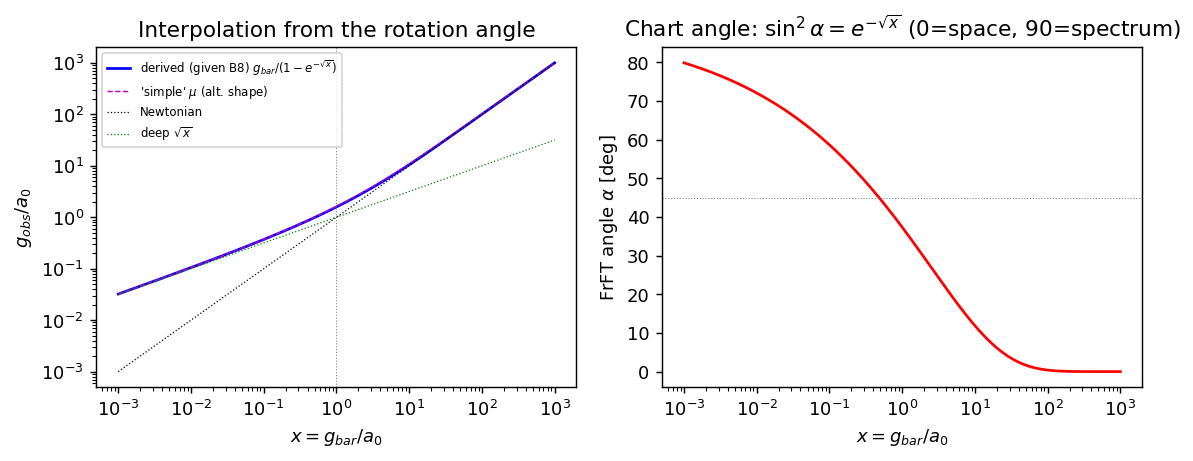

PASS deep slope 0.514 → 1/2 and Newtonian slope 1.000 → 1
PASS the discriminant ν_simple − ν_frc peaks at 0.0512 at x = 5.22 (the paper's 0.051 at 5.2)
PASS pinning check 1: a barrier κx^β gives deep slope 1 − β for β = 0.4, 0.5, 0.6
PASS pinning check 2: the knee sits at 1/κ² for κ = 1, 0.93, 1.1 (3 cases)
PASS the figure written (cons3_interpolation.pdf, .png)
  [PASS] dark.interpolation     CHART  [32:B8, 32:C6, 32:X4] the interpolation from the rotation angle: deep slope 1/2 and Newtonian slope 1; the discr  --  5 checks, 0.5 s

— rar_shape.py
2692 SPARC points; a0 = cH0/2pi = 1.0422e-10 m/s^2 (H0 = 67.4); the RAR fit g_dagger = 1.20e-10
17 bins of 0.2 dex in log g_b with >= 10 points; the uncertainty of a bin is its scatter (0.03-0.13 dex)

== 1. both forms at the fixed floor a0 = cH0/2pi
    log g_b    N  <log g_obs>     sd      exp   simple  res exp  res smp
      -11.9   17      -10.846  0.172  -10.917  -10.917   +0.071   +0.071
      -11.7   62      -10.757  0.181  -10.811  -1

figure saved


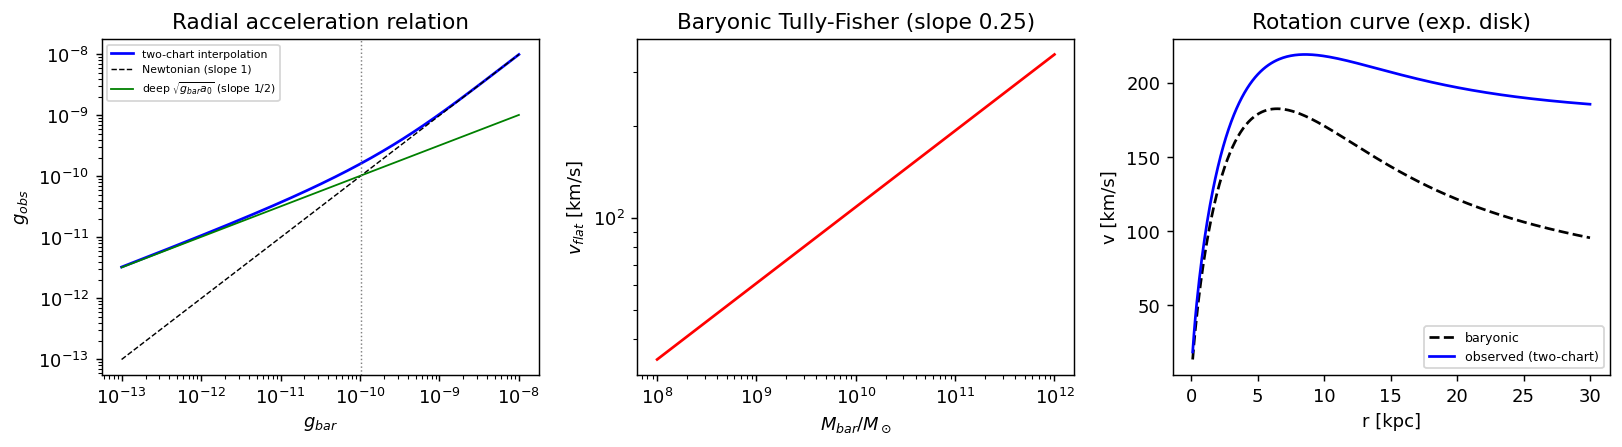

PASS a₀ = cH₀/2π = 1.0422e-10 at H₀ = 67.4 (1.042 × 10⁻¹⁰)
PASS RAR deep-regime slope 0.514 → 1/2
PASS BTFR slope 0.250 → 1/4
PASS v_flat(5 × 10¹⁰ M⊙) = 162 km/s (the paper's 162)
PASS the exponential-disk curve: the registered speed flattens (scipy present)
PASS the figure written (cons2_rar_btfr.pdf, .png)
  [PASS] dark.deep_mond         CHART  [32:C2, 32:C4, 32:C5, 32:X2, 32:X3] the two-chart Gauss law: a₀ = cH₀/2π = 1.042 × 10⁻¹⁰ at H₀ = 67.4; the RAR deep-regime slo  --  6 checks, 0.7 s


In [5]:
for fam in ["dark.interpolation", "dark.rar_shape", "dark.deep_mond"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)

## The scatter, the clusters, the predictions
The SPARC residual test at fixed a₀ = cH₀/2π: intrinsic scatter 0.038 dex, 0.04 at the knee rising to 0.13 in the deep regime, the bound δα ≲ 3.5°, no within-galaxy correlation with 1/V_flat over 116 disks, the 0.14-dex amplitude-sum boost; the coherence-matrix amplitude law N_eff for clusters (the Bullet selection and the core addition in one law, the factor-two closure a conjecture); the falsifiable predictions computed — a₀(z) ∝ H(z), the two-variable scatter law, the wide-binary enhancement with the Galactic external field, the pressure-supported offset.

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `dark.rar_scatter` | `rar_scatter.py` | CHART | the SPARC residual test at fixed a₀ = cH₀/2π: intrinsic scatter 0.038 dex overall, 0.04 at the knee, rising to ≈ 0.13 at x ≈ 0.02; the two-variable law bounding δα ≲ 3.5° (σ_v/v = 0.1–0.2 excluded, O2); no correlation of the within-galaxy scatter with 1/V_flat over 116 disks (ρ = −0.02); a gas–disk–bulge amplitude sum would boost the RAR by 0.14 dex (O1's within-galaxy constraint); ν(0.1) = 3.69 [approx, data] | 32:C8, 32:P2, 32:X5, 32:O1, 32:O2 |
| `dark.cluster_coherent` | `cluster_coherent.py` | CHART | the coherence-matrix amplitude law: N_eff = (Σ√g)²/Σg equals N for equal components and is suppressed by a dominant BCG (4:1:1 → 2.67); the core boost √N_eff with N_core = 6 (2.45) decaying to 1 by ~Mpc in the illustrative radial profile — the Bullet selection (C → 0) and the core addition (C → 1) in one law, the factor-two closure a conjecture (O1) [illustrative] | 32:C10, 32:X7, 32:X8, 32:O1 |
| `dark.predictions` | `predictions.py` | CHART | the falsifiable predictions computed: a₀(z) = cH(z)/2π with v_flat ∝ E(z)^(1/4) (+7 %, +15 %, +31 % at z = 0.5, 1, 2); the two-variable scatter law σ(x, σ_v/v) (0.27 dex at x = 0.01, σ_v/v = 0.1); the wide-binary velocity enhancement with the Galactic external field 1.8a₀ (√ν − 1 = 12–16 % at 10–40 kAU, the paper's 10–30 %); the pressure-supported coherence offset √w (−0.05 to −0.15 dex for σ_v/v = 0.5–1) [approx] | 32:P1, 32:P2, 32:P3, 32:P4 |

Ledger rows witnessed: 32:C8, 32:C10, 32:O1, 32:O2, 32:P1, 32:P2, 32:P3, 32:P4, 32:X5, 32:X7, 32:X8.

In [6]:
for fam in ["dark.rar_scatter", "dark.cluster_coherent", "dark.predictions"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)


— rar_scatter.py
a0 = cH0/2pi = 1.0422e-10 m/s^2 (H0 = 67.4)

== 1. 2692 SPARC points, a0 fixed: mean +0.0179 dex, rms 0.1327, expected 0.1272, intrinsic 0.0379 dex
  PASS  intrinsic scatter at fixed a0 below 0.05 dex
  PASS  total rms within 0.01 dex of the error-expected rms (error-dominated)

== 2. intrinsic scatter binned in log10 x
   [ -2.0, -1.5) N= 160  mean +0.009  rms 0.174  expected 0.109  intrinsic 0.135
   [ -1.5, -1.0) N= 700  mean +0.012  rms 0.141  expected 0.129  intrinsic 0.058
   [ -1.0, -0.5) N= 598  mean +0.021  rms 0.125  expected 0.122  intrinsic 0.028
   [ -0.5,  0.0) N= 549  mean +0.030  rms 0.125  expected 0.118  intrinsic 0.043
   [  0.0,  0.5) N= 379  mean +0.024  rms 0.136  expected 0.128  intrinsic 0.046
   [  0.5,  1.0) N= 228  mean -0.005  rms 0.111  expected 0.151  intrinsic 0.000
   [  1.0,  1.5) N=  65  mean +0.016  rms 0.079  expected 0.171  intrinsic 0.000
  PASS  knee bins (0.1 < x < 3) intrinsic within 0.03-0.05 dex
  PASS  deep-regime rise: intr

## The figures
The paper's two figures regenerated into figures/: fig_rar.pdf (the RAR with the rational alternative and the exponential-disk rotation curve) and fig_mechanism.pdf (the first-passage collapse and the chart angle).

| id | script | kind | claim | ledger rows |
|---|---|---|---|---|
| `dark.make_figures` | `make_figures.py` | CHART | the paper's two figures regenerated (fig_rar.pdf: the RAR with the rational alternative and the exponential-disk rotation curve; fig_mechanism.pdf: the first-passage collapse and the chart angle), written to figures/ | 32:V2 |

Ledger rows witnessed: 32:V2.


— make_figures.py


fig_rar.pdf saved


fig_mechanism.pdf saved


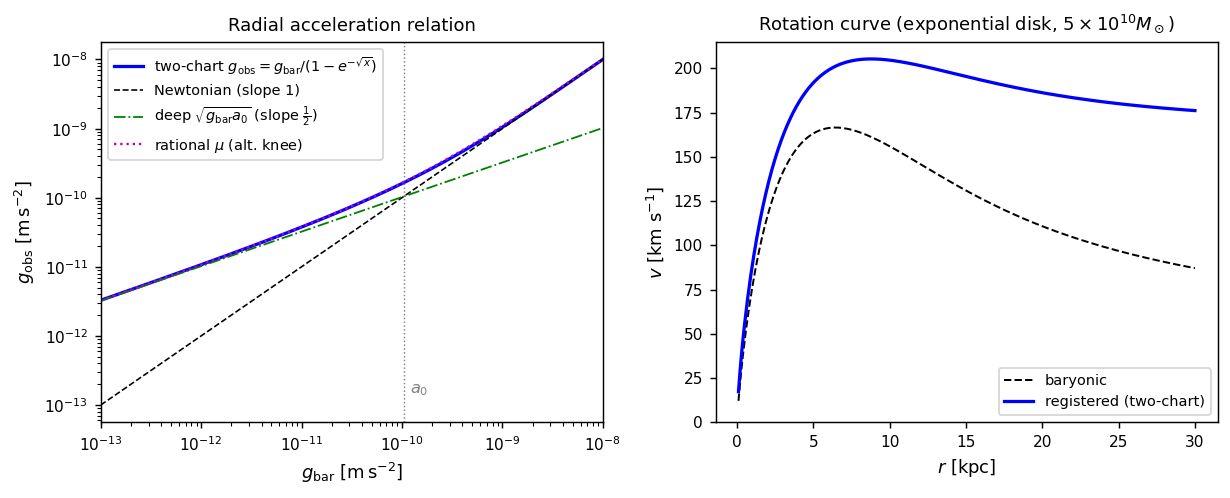

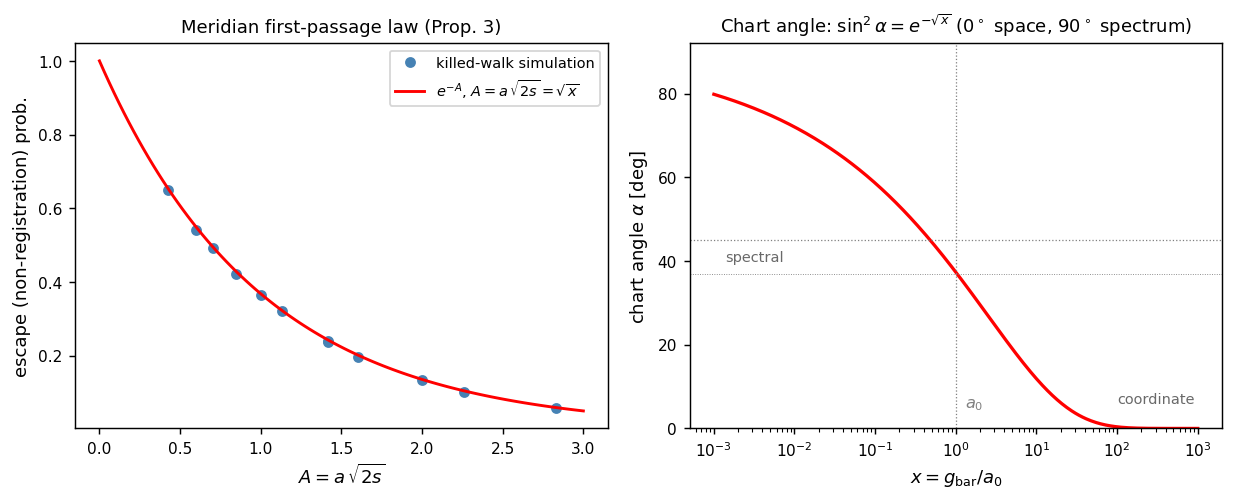

PASS fig_rar.pdf (and .png) regenerated in figures/
PASS fig_mechanism.pdf (and .png) regenerated in figures/
  [PASS] dark.make_figures      CHART  [32:V2] the paper's two figures regenerated (fig_rar.pdf: the RAR with the rational alternative an  --  2 checks, 4.3 s


In [7]:
for fam in ["dark.make_figures"]:
    print(f"\n— {gc.script_of(fam)}.py"); gc.run_block(fam)

## Summary
Writes `results.json` (one record per family: id, the ledger row(s) witnessed, script, kind, claim, PASS/FAIL, the micro-check count) and raises if any family failed.

In [8]:
ok = gc.summary(write=True)
failed = [r["id"] for r in gc.RESULTS if not r["ok"]]
assert ok, f"FAILED families: {failed}"
print(f"all {len(gc.RESULTS)} families pass ({len(gc.MICRO)} micro-checks); records in results.json")


SUMMARY: 13/13 checks passed (64 micro-checks)
all 13 families pass (64 micro-checks); records in results.json
